Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN

from sklearn.decomposition import PCA

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import silhouette_score

Upload Dataset

In [2]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv("Country-data.csv")

df.head()

Saving Country-data.csv to Country-data (1).csv


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


Basic Exploration

In [3]:
print(df.shape)

print(df.info())

print(df.describe())

print(df.isnull().sum())

df.head()

(167, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB
None
       child_mort     exports      health     imports         income  \
count  167.000000  167.000000  167.000000  167.000000     167.000000   
mean    38.270060   41.108976    6.815689   46.890215   17144.688623   
std     40.328931   27.412010    2.746837   24.209589   19278.067698   
min      2.600000    0.109000    1.81

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


EDA

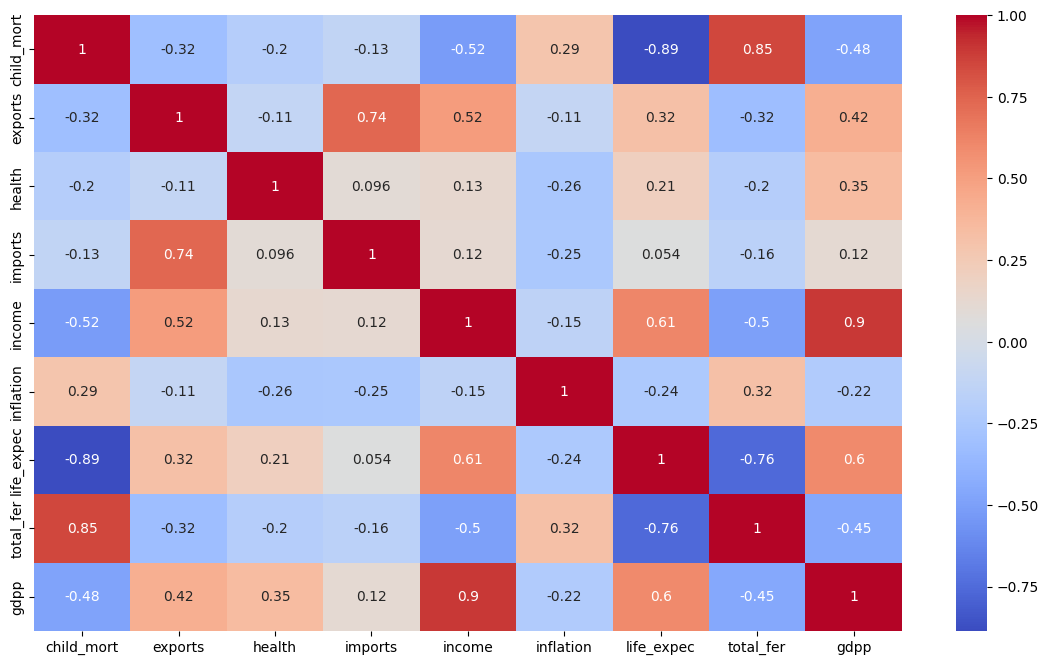

In [4]:
plt.figure(figsize=(14,8))

sns.heatmap(df.corr(numeric_only=True),
            annot=True,
            cmap="coolwarm")

plt.show()

Distribution

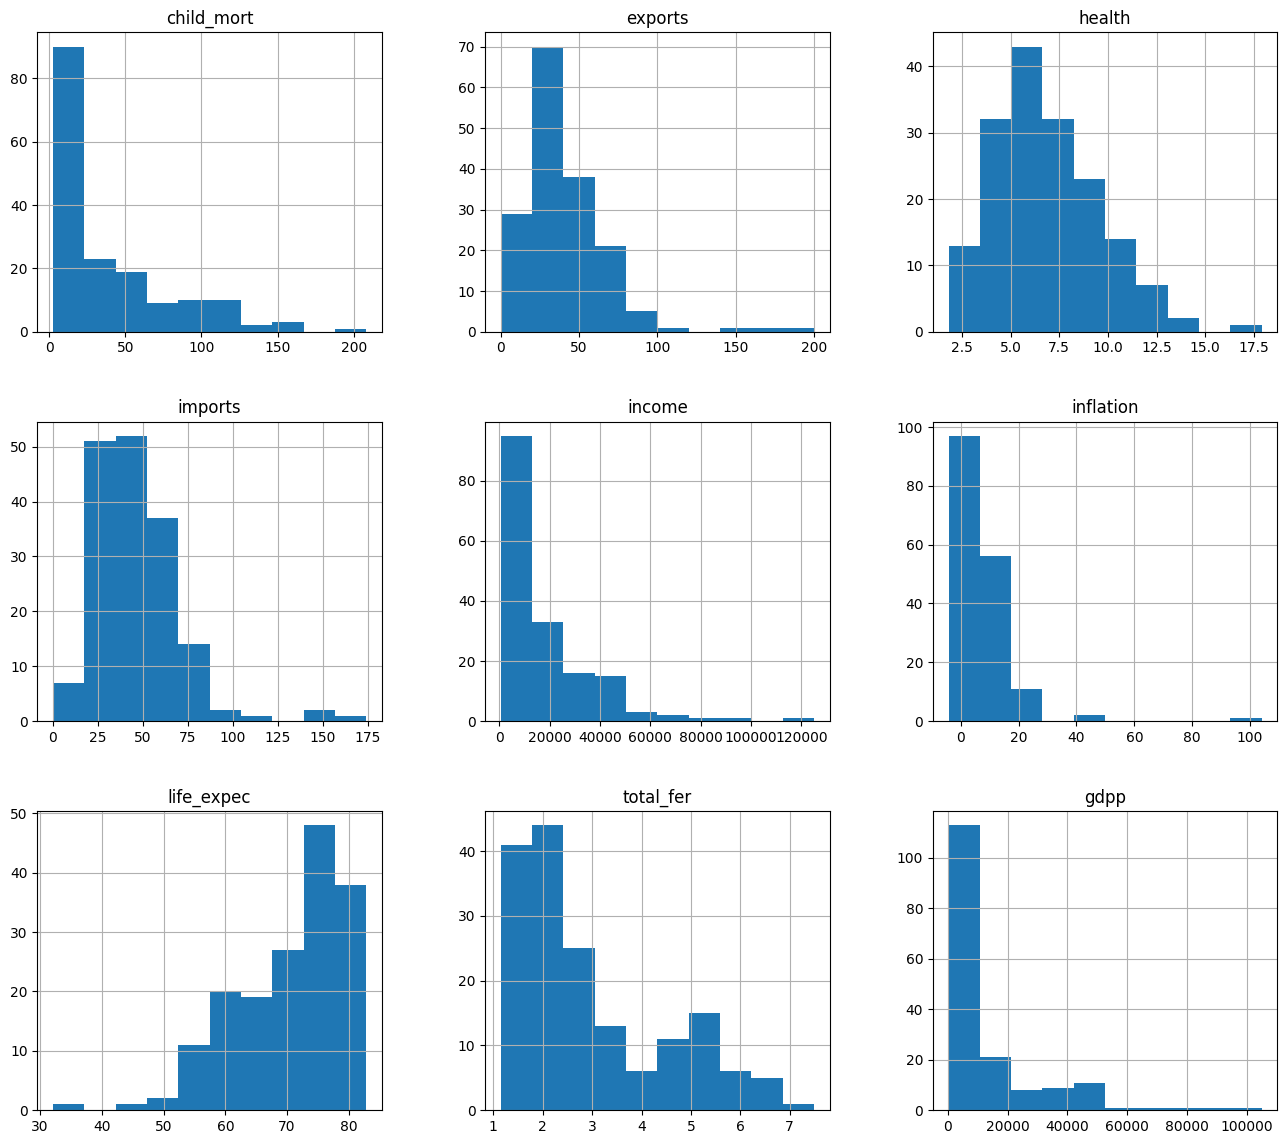

In [5]:
df.hist(figsize=(16,14))
plt.show()

Feature Scaling

In [6]:
country=df["country"]

X=df.drop("country",axis=1)

scaler=StandardScaler()

X_scaled=scaler.fit_transform(X)

KMeans Clustering

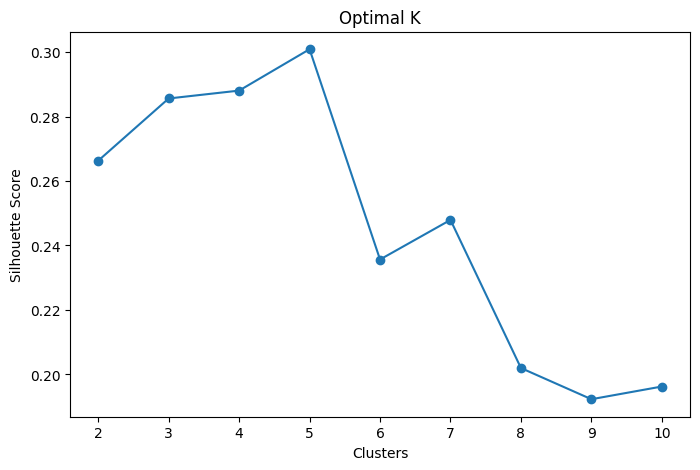

In [7]:
scores=[]

for k in range(2,11):

    model=KMeans(n_clusters=k,
                 random_state=42)

    labels=model.fit_predict(X_scaled)

    scores.append(silhouette_score(X_scaled,
                                   labels))

plt.figure(figsize=(8,5))

plt.plot(range(2,11),
         scores,
         marker='o')

plt.xlabel("Clusters")

plt.ylabel("Silhouette Score")

plt.title("Optimal K")

plt.show()

Choose K=3

In [8]:
kmeans=KMeans(n_clusters=3,
              random_state=42)

df["Cluster"]=kmeans.fit_predict(X_scaled)

print(df["Cluster"].value_counts())

Cluster
0    86
2    45
1    36
Name: count, dtype: int64


DBSCAN

In [9]:
dbscan=DBSCAN(eps=1.5,
              min_samples=5)

db_labels=dbscan.fit_predict(X_scaled)

df["DBSCAN"]=db_labels

print(df["DBSCAN"].value_counts())

DBSCAN
 0    137
-1     30
Name: count, dtype: int64


PCA Visualization

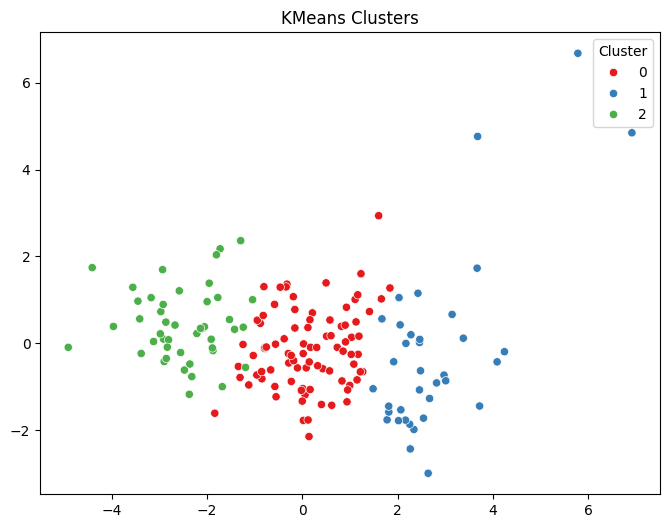

In [10]:
pca=PCA(n_components=2)

components=pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))

sns.scatterplot(x=components[:,0],
                y=components[:,1],
                hue=df["Cluster"],
                palette="Set1")

plt.title("KMeans Clusters")

plt.show()

Preparation of Classification Dataset
KMeans Cluster becomes target.

In [11]:
X=df.drop(["country",
           "Cluster",
           "DBSCAN"],axis=1)

y=df["Cluster"]

X_train,X_test,y_train,y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

Random Forest

In [12]:
rf=RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf.fit(X_train,y_train)

rf_pred=rf.predict(X_test)

print("Random Forest Accuracy")

print(accuracy_score(y_test,
                     rf_pred))

print(classification_report(y_test,
                            rf_pred))

Random Forest Accuracy
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



Feature Importance

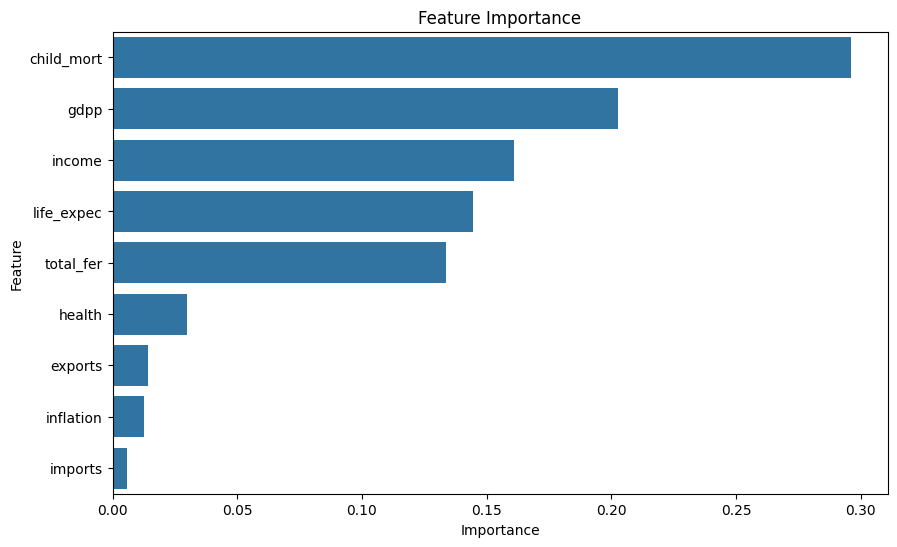

In [13]:
importance=pd.DataFrame({

"Feature":X.columns,

"Importance":rf.feature_importances_

})

importance=importance.sort_values(
    by="Importance",
    ascending=False
)

plt.figure(figsize=(10,6))

sns.barplot(data=importance,
            x="Importance",
            y="Feature")

plt.title("Feature Importance")

plt.show()

XGBoost

In [14]:
xgb=XGBClassifier(

n_estimators=300,

learning_rate=0.05,

max_depth=4,

random_state=42,

eval_metric="mlogloss"

)

xgb.fit(X_train,y_train)

pred=xgb.predict(X_test)

print("XGBoost Accuracy")

print(accuracy_score(y_test,pred))

print(classification_report(y_test,pred))

XGBoost Accuracy
1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00         8
           2       1.00      1.00      1.00         6

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



Confusion Matrix

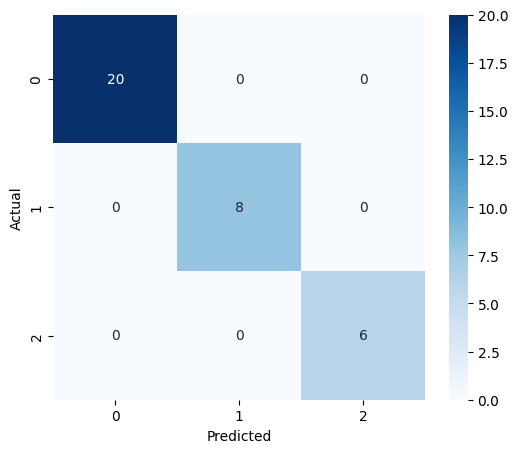

In [15]:
cm=confusion_matrix(y_test,pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            cmap="Blues",
            fmt='d')

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

Customer Intelligence Insights

In [16]:
cluster_summary=df.groupby("Cluster").mean(numeric_only=True)

print(cluster_summary)

print("\nCustomer Intelligence Insights")

for cluster in cluster_summary.index:

    print(f"\nCluster {cluster}")

    print(cluster_summary.loc[cluster])

         child_mort    exports    health    imports        income  inflation  \
Cluster                                                                        
0         22.456977  40.273128  6.251047  47.362394  12321.744186   7.720884   
1          5.000000  58.738889  8.807778  51.491667  45672.222222   2.671250   
2         95.106667  28.602444  6.301111  42.306667   3539.844444  11.986778   

         life_expec  total_fer          gdpp    DBSCAN  
Cluster                                                 
0         72.566279   2.340349   6461.767442 -0.069767  
1         80.127778   1.752778  42494.444444 -0.250000  
2         59.055556   5.065333   1766.711111 -0.333333  

Customer Intelligence Insights

Cluster 0
child_mort       22.456977
exports          40.273128
health            6.251047
imports          47.362394
income        12321.744186
inflation         7.720884
life_expec       72.566279
total_fer         2.340349
gdpp           6461.767442
DBSCAN           -0.069767
N